# Лабораторна робота 1: Логістична регресія з нуля


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 1  
**Тема лабораторної:** Базова логістична регресія з нуля


## Цілі лабораторної

- Реалізувати логістичну регресію з нуля за допомогою NumPy

- Зрозуміти бінарну класифікацію як задачу оптимізації

- Реалізувати градієнтний спуск для логістичної втрати

- Візуалізувати межі рішень (decision boundaries)

- Порівняти з `sklearn.LogisticRegression`


## Передумови

- Базові знання Python та NumPy

- Розуміння градієнтного спуску

- Базові знання лінійної алгебри

## Налаштування середовища

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

from logistic_regression_student import sigmoid, logistic_loss, predict, compute_accuracy, train_logistic_regression, train_logistic_regression_with_weights


## Вступ

У цій лабораторній роботі ми реалізуємо логістичну регресію з нуля, використовуючи NumPy. Логістична регресія - це базовий алгоритм бінарної класифікації, який моделює ймовірність класу за допомогою логістичної (сигмоїдної) функції.

## Демонстрації функцій NumPy

Перш ніж ми почнемо реалізовувати логістичну регресію, продемонструємо ключові функції NumPy, які будемо використовувати. Це допоможе переконатися, що ми розуміємо ці базові операції, перш ніж застосовувати їх в алгоритмі.

**Примітка**: Ці демонстрації наведено тут, оскільки це перший раз, коли ці функції використовуються в курсі. У наступних лабораторних ми можемо використовувати ці функції без повторної демонстрації.

In [3]:
# NumPy Function Demonstration: np.zeros
# This is the first time np.zeros is used in the course

# np.zeros creates an array filled with zeros
# Useful for initializing weights and other arrays

# Example 1: 1D array
arr1d = np.zeros(5)
print(f"1D array of zeros: {arr1d}")
print(f"Shape: {arr1d.shape}")

# Example 2: 2D array
arr2d = np.zeros((3, 4))
print(f"\n2D array of zeros:\n{arr2d}")
print(f"Shape: {arr2d.shape}")

# Example 3: Common use case in ML - initialize weight vector
n_features = 2
weights = np.zeros(n_features)
print(f"\nWeight vector initialization: {weights}")
print(f"Weight shape: {weights.shape}")


1D array of zeros: [0. 0. 0. 0. 0.]
Shape: (5,)

2D array of zeros:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Shape: (3, 4)

Weight vector initialization: [0. 0.]
Weight shape: (2,)


In [4]:
# NumPy Function Demonstration: np.dot
# This is the first time np.dot is used in the course

# np.dot performs matrix multiplication or dot product
# Essential for linear algebra operations in ML

# Example 1: Dot product of two 1D arrays (scalar result)
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
result1 = np.dot(a, b)
print(f"Dot product of {a} and {b}: {result1}")
print(f"Result type: {type(result1)}")

# Example 2: Matrix multiplication (2D arrays)
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
result2 = np.dot(A, B)
print(f"\nMatrix A:\n{A}")
print(f"Matrix B:\n{B}")
print(f"Matrix product A @ B:\n{result2}")

# Example 3: Common use case in ML - linear combination
# X is feature matrix (n_samples, n_features), w is weight vector (n_features,)
X_example = np.array([[1, 2], [3, 4], [5, 6]])  # 3 samples, 2 features
w_example = np.array([0.5, -0.3])  # 2 weights
z = np.dot(X_example, w_example)  # Result: (3,) - one value per sample
print(f"\nML example - Linear combination:")
print(f"X shape: {X_example.shape}, w shape: {w_example.shape}")
print(f"z = X @ w = {z}")
print(f"z shape: {z.shape}")


Dot product of [1 2 3] and [4 5 6]: 32
Result type: <class 'numpy.int64'>

Matrix A:
[[1 2]
 [3 4]]
Matrix B:
[[5 6]
 [7 8]]
Matrix product A @ B:
[[19 22]
 [43 50]]

ML example - Linear combination:
X shape: (3, 2), w shape: (2,)
z = X @ w = [-0.1  0.3  0.7]
z shape: (3,)


In [5]:
# NumPy Function Demonstration: np.exp
# This is the first time np.exp is used in the course

# np.exp computes the exponential function e^x for each element
# Critical for sigmoid function and probability calculations

# Example 1: Basic usage with scalar
x1 = 1.0
result1 = np.exp(x1)
print(f"exp({x1}) = {result1:.4f}")
print(f"Note: e ≈ 2.71828, so exp(1) ≈ 2.718")

# Example 2: Array input
x2 = np.array([0, 1, -1, 2])
result2 = np.exp(x2)
print(f"\nInput array: {x2}")
print(f"exp(x): {result2}")
print(f"Note: exp(0) = 1, exp(negative) < 1, exp(positive) > 1")

# Example 3: Common use case - sigmoid function component
# Sigmoid uses exp(-z), so we need to understand exp behavior
z_values = np.array([-5, -2, 0, 2, 5])
exp_neg_z = np.exp(-z_values)
sigmoid_values = 1 / (1 + exp_neg_z)
print(f"\nSigmoid calculation example:")
print(f"z values: {z_values}")
print(f"exp(-z): {exp_neg_z}")
print(f"sigmoid(z) = 1/(1+exp(-z)): {sigmoid_values}")
print(f"Note: Large negative z → exp(-z) very large → sigmoid → 0")
print(f"      Large positive z → exp(-z) very small → sigmoid → 1")


exp(1.0) = 2.7183
Note: e ≈ 2.71828, so exp(1) ≈ 2.718

Input array: [ 0  1 -1  2]
exp(x): [1.         2.71828183 0.36787944 7.3890561 ]
Note: exp(0) = 1, exp(negative) < 1, exp(positive) > 1

Sigmoid calculation example:
z values: [-5 -2  0  2  5]
exp(-z): [1.48413159e+02 7.38905610e+00 1.00000000e+00 1.35335283e-01
 6.73794700e-03]
sigmoid(z) = 1/(1+exp(-z)): [0.00669285 0.11920292 0.5        0.88079708 0.99330715]
Note: Large negative z → exp(-z) very large → sigmoid → 0
      Large positive z → exp(-z) very small → sigmoid → 1


In [6]:
# NumPy Function Demonstration: np.clip
# This is the first time np.clip is used in the course

# np.clip limits array values to a specified range
# Essential for numerical stability in ML algorithms

# Example 1: Basic clipping
arr = np.array([-5, -2, 0, 3, 8, 10])
clipped = np.clip(arr, 0, 5)
print(f"Original array: {arr}")
print(f"Clipped to [0, 5]: {clipped}")
print(f"Values < 0 become 0, values > 5 become 5")

# Example 2: Clipping probabilities to avoid log(0)
probs = np.array([0.001, 0.5, 0.999, 0.0, 1.0])
clipped_probs = np.clip(probs, 1e-15, 1 - 1e-15)
print(f"\nProbability clipping example:")
print(f"Original probabilities: {probs}")
print(f"Clipped probabilities: {clipped_probs}")
print(f"Note: Prevents log(0) errors in loss calculations")

# Example 3: Common use case - numerical stability in sigmoid
# Very large z values can cause exp(-z) to overflow
z_large = np.array([-1000, -500, 0, 500, 1000])
z_clipped = np.clip(z_large, -500, 500)  # Safe range for exp
exp_safe = np.exp(-z_clipped)
print(f"\nNumerical stability example:")
print(f"Large z values: {z_large}")
print(f"Clipped z values: {z_clipped}")
print(f"exp(-z_clipped): {exp_safe}")
print(f"Note: Prevents overflow/underflow in exponential calculations")


Original array: [-5 -2  0  3  8 10]
Clipped to [0, 5]: [0 0 0 3 5 5]
Values < 0 become 0, values > 5 become 5

Probability clipping example:
Original probabilities: [0.001 0.5   0.999 0.    1.   ]
Clipped probabilities: [1.00e-03 5.00e-01 9.99e-01 1.00e-15 1.00e+00]
Note: Prevents log(0) errors in loss calculations

Numerical stability example:
Large z values: [-1000  -500     0   500  1000]
Clipped z values: [-500 -500    0  500  500]
exp(-z_clipped): [1.40359222e+217 1.40359222e+217 1.00000000e+000 7.12457641e-218
 7.12457641e-218]
Note: Prevents overflow/underflow in exponential calculations


In [7]:
# NumPy Function Demonstration: np.mean
# This is the first time np.mean is used in the course

# np.mean computes the arithmetic mean (average) of array elements
# Used extensively for averaging losses, gradients, and metrics

# Example 1: Basic mean calculation
arr = np.array([1, 2, 3, 4, 5])
mean_val = np.mean(arr)
print(f"Array: {arr}")
print(f"Mean: {mean_val}")
print(f"Formula: (1+2+3+4+5)/5 = {mean_val}")

# Example 2: Mean along axis (for 2D arrays)
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
mean_all = np.mean(matrix)
mean_axis0 = np.mean(matrix, axis=0)  # Mean of each column
mean_axis1 = np.mean(matrix, axis=1)  # Mean of each row
print(f"\nMatrix:\n{matrix}")
print(f"Mean of all elements: {mean_all}")
print(f"Mean along axis=0 (columns): {mean_axis0}")
print(f"Mean along axis=1 (rows): {mean_axis1}")

# Example 3: Common use case - average loss over batch
losses = np.array([0.5, 0.3, 0.2, 0.4, 0.35])
avg_loss = np.mean(losses)
print(f"\nML example - Average loss:")
print(f"Individual losses: {losses}")
print(f"Average loss: {avg_loss:.4f}")
print(f"Note: This is how we compute loss over a batch of samples")



Array: [1 2 3 4 5]
Mean: 3.0
Formula: (1+2+3+4+5)/5 = 3.0

Matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Mean of all elements: 5.0
Mean along axis=0 (columns): [4. 5. 6.]
Mean along axis=1 (rows): [2. 5. 8.]

ML example - Average loss:
Individual losses: [0.5  0.3  0.2  0.4  0.35]
Average loss: 0.3500
Note: This is how we compute loss over a batch of samples


In [8]:
# NumPy Function Demonstration: np.log
# This is the first time np.log is used in the course

# np.log computes the natural logarithm (base e) of array elements
# Essential for logarithmic loss functions

# Example 1: Basic logarithm
values = np.array([1, np.e, np.e**2, 10])
log_values = np.log(values)
print(f"Values: {values}")
print(f"log(values): {log_values}")
print(f"Note: log(e) = 1, log(e²) = 2")

# Example 2: Logarithm of probabilities (must be > 0)
probs = np.array([0.1, 0.5, 0.9, 0.99])
log_probs = np.log(probs)
print(f"\nProbability logarithms:")
print(f"Probabilities: {probs}")
print(f"log(probabilities): {log_probs}")
print(f"Note: log(1) = 0, log(< 1) < 0, log(0) = -inf (error!)")

# Example 3: Common use case - log loss component
# Binary cross-entropy uses log(p) and log(1-p)
y_true = np.array([1, 0, 1, 0])
y_pred = np.array([0.9, 0.1, 0.8, 0.2])
# Clip to avoid log(0)
y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
log_loss_components = -(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
print(f"\nML example - Log loss components:")
print(f"True labels: {y_true}")
print(f"Predicted probabilities: {y_pred}")
print(f"Log loss components: {log_loss_components}")
print(f"Average log loss: {np.mean(log_loss_components):.4f}")


Values: [ 1.          2.71828183  7.3890561  10.        ]
log(values): [0.         1.         2.         2.30258509]
Note: log(e) = 1, log(e²) = 2

Probability logarithms:
Probabilities: [0.1  0.5  0.9  0.99]
log(probabilities): [-2.30258509 -0.69314718 -0.10536052 -0.01005034]
Note: log(1) = 0, log(< 1) < 0, log(0) = -inf (error!)

ML example - Log loss components:
True labels: [1 0 1 0]
Predicted probabilities: [0.9 0.1 0.8 0.2]
Log loss components: [0.10536052 0.10536052 0.22314355 0.22314355]
Average log loss: 0.1643


In [9]:
# NumPy Function Demonstration: np.linalg.norm
# This is the first time np.linalg.norm is used in the course

# np.linalg.norm computes vector or matrix norm
# Useful for measuring distances and differences between vectors

# Example 1: Vector norm (Euclidean distance from origin)
vec = np.array([3, 4])
norm = np.linalg.norm(vec)
print(f"Vector: {vec}")
print(f"Euclidean norm (L2): {norm}")
print(f"Verification: sqrt(3² + 4²) = sqrt(9 + 16) = {norm}")

# Example 2: Different norm types
vec2 = np.array([-2, 3, -1])
l2_norm = np.linalg.norm(vec2)  # Default: L2 norm
l1_norm = np.linalg.norm(vec2, ord=1)  # L1 norm (sum of absolute values)
print(f"\nVector: {vec2}")
print(f"L2 norm (Euclidean): {l2_norm:.4f}")
print(f"L1 norm (Manhattan): {l1_norm}")

# Example 3: Common use case - measuring weight differences
# Compare two weight vectors to see how similar they are
w1 = np.array([0.5, -0.3, 0.8])
w2 = np.array([0.52, -0.28, 0.82])
weight_diff = np.linalg.norm(w1 - w2)
print(f"\nML example - Weight vector comparison:")
print(f"Weight vector 1: {w1}")
print(f"Weight vector 2: {w2}")
print(f"Difference norm: {weight_diff:.6f}")
print(f"Note: Smaller norm = more similar weights")


Vector: [3 4]
Euclidean norm (L2): 5.0
Verification: sqrt(3² + 4²) = sqrt(9 + 16) = 5.0

Vector: [-2  3 -1]
L2 norm (Euclidean): 3.7417
L1 norm (Manhattan): 6.0

ML example - Weight vector comparison:
Weight vector 1: [ 0.5 -0.3  0.8]
Weight vector 2: [ 0.52 -0.28  0.82]
Difference norm: 0.034641
Note: Smaller norm = more similar weights


Data shape: (100, 2)
Labels shape: (100,)


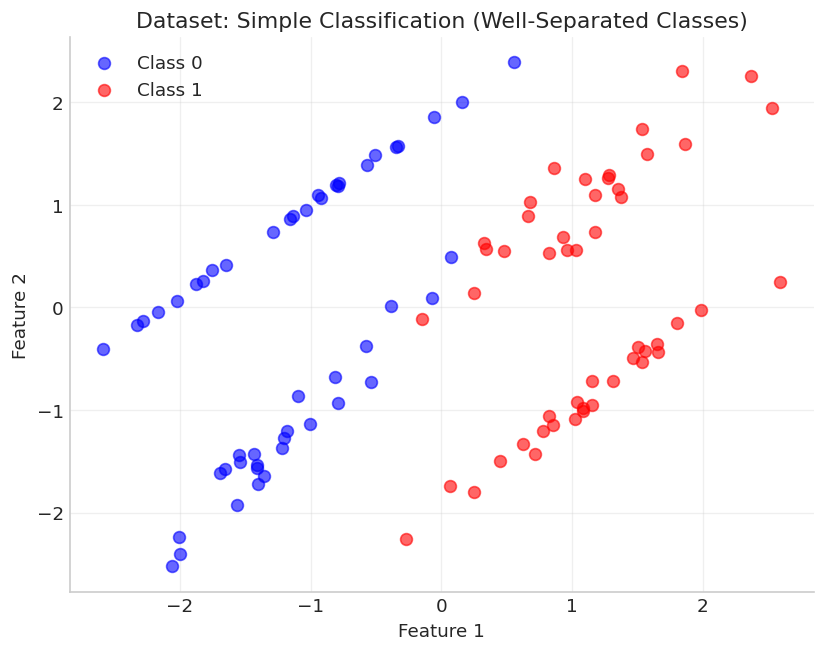

In [10]:
# Generate sample data
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=2, random_state=42)

print(f"Data shape: {X.shape}")
print(f"Labels shape: {y.shape}")

plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', alpha=0.6, s=50)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', alpha=0.6, s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset: Simple Classification (Well-Separated Classes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Реалізація



### Крок 1: Реалізувати сигмоїдну функцію

Сигмоїдна функція відображає будь-яке дійсне число на значення між 0 і 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Сигмоїдна функція є основою логістичної регресії. Вона відображає будь-яке дійсне число на значення ймовірності між 0 і 1.

**Що потрібно зрозуміти:**
- Математична формула: $\sigma(z) = \frac{1}{1 + e^{-z}}$
- Чому потрібна чисельна стабільність (обрізання для запобігання переповненню)
- Як вона перетворює лінійні комбінації на ймовірності

**Завдання для реалізації:** Завершіть реалізацію сигмоїдної функції. Зверніть увагу на чисельну стабільність - дуже великі або дуже малі значення z можуть спричинити проблеми з числовими обрахунками.

### Крок 2: Реалізувати логістичну втрату

Логістична втрата (бінарна перехресна ентропія) для одного прикладу:

$$L(y, \hat{y}) = -[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$

Логістична втрата (бінарна перехресна (крос-) ентропія) вимірює, наскільки добре наші прогнози відповідають справжнім міткам.

**Ключові концепції:**
- Вона сильніше штрафує впевнені неправильні прогнози
- Вона спеціально розроблена для роботи із ймовірностями (діапазон 0-1)
- Втрата зменшується, коли прогнози наближаються до справжніх міток

**Завдання для реалізації:** Реалізуйте функцію логістичної втрати. Пам'ятайте обрізати ймовірності, щоб уникнути помилок log(0).

### Крок 3: Реалізувати градієнтний спуск

Оновлення ваг за допомогою:

$$w = w - \alpha \nabla_w L$$

Градієнтний спуск оновлює параметри моделі для мінімізації функції втрат.

**Як це працює:**
1. Обчислюємо градієнт (похідну) втрати по відношенню до кожного параметра
2. Оновлюємо параметри в напрямку, що зменшує втрату
3. Повторюємо до збіжності

**Завдання для реалізації:** Реалізуйте обчислення градієнта та крок оновлення параметрів. Градієнт для логістичної регресії має просту форму.

### Крок 4: Навчити модель

**Завдання для реалізації:** Вивчіть код нижче та запустіть його, щоб побачити результати. Змініть параметри, щоб спостерігати, як вони впливають на вихід.

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.1695
Epoch 200, Loss: 0.1196
Epoch 300, Loss: 0.0988
Epoch 400, Loss: 0.0869
Epoch 500, Loss: 0.0790
Epoch 600, Loss: 0.0733
Epoch 700, Loss: 0.0689
Epoch 800, Loss: 0.0654
Epoch 900, Loss: 0.0626


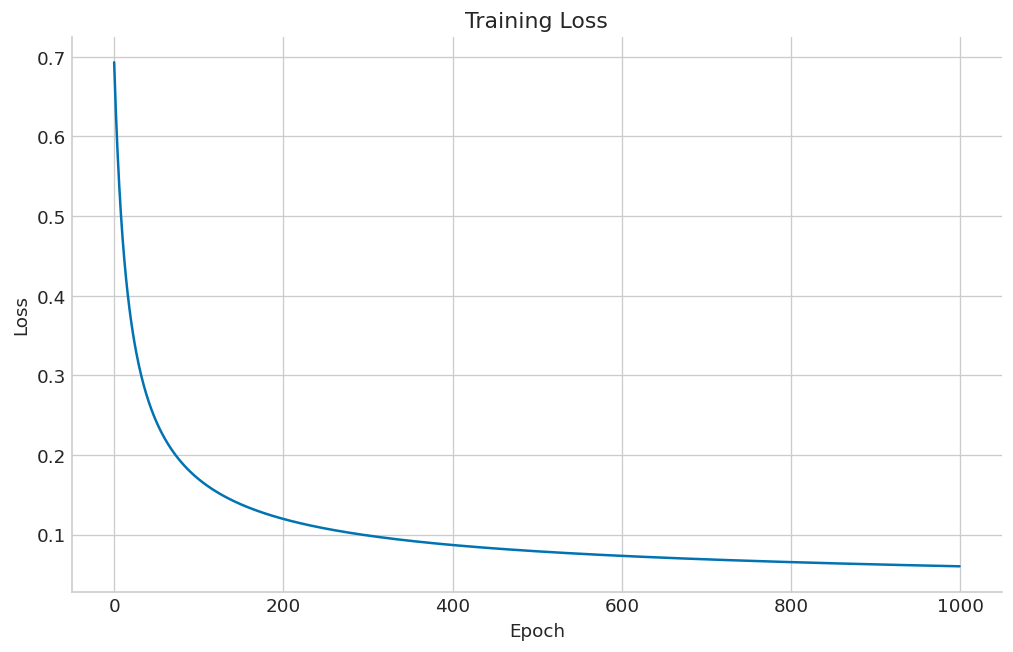

In [11]:
# Train the model
w, b, losses = train_logistic_regression(X, y, learning_rate=0.1, epochs=1000)

# Plot training curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

### Крок 5: Візуалізувати межу рішення

**Завдання для реалізації:** Вивчіть код нижче та запустіть його, щоб побачити результати. Змініть параметри, щоб спостерігати, як вони впливають на вихід.

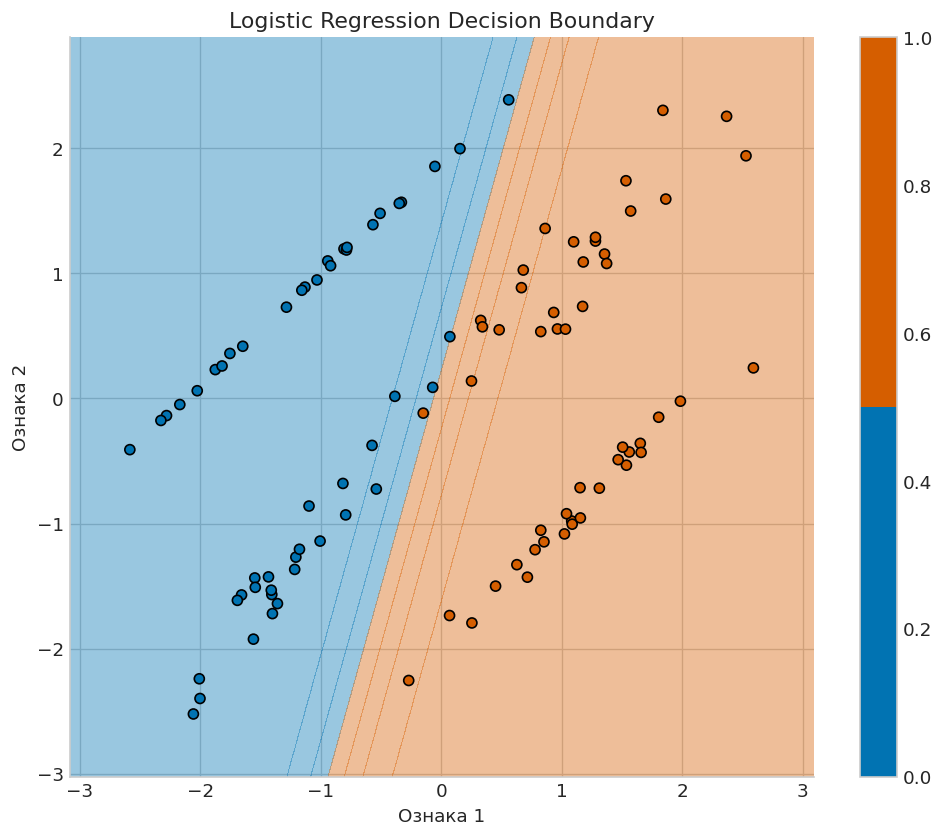

In [12]:
# Visualize decision boundary
from visualization import plot_decision_boundary

def predict(X, w, b):
    z = np.dot(X, w) + b
    return (sigmoid(z) > 0.5).astype(int)

fig, ax = plot_decision_boundary(X, y, lambda X_test: sigmoid(np.dot(X_test, w) + b))
plt.title('Logistic Regression Decision Boundary')
plt.show()

## Порівняння з sklearn

Порівняємо нашу реалізацію з `LogisticRegression` зі `sklearn`:

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# sklearn implementation
sklearn_model = LogisticRegression(random_state=42)
sklearn_model.fit(X, y)
sklearn_pred = sklearn_model.predict(X)
sklearn_acc = accuracy_score(y, sklearn_pred)

# Our implementation
our_pred = predict(X, w, b)
our_acc = compute_accuracy(y, our_pred)

print(f"sklearn accuracy: {sklearn_acc:.4f}")
print(f"Our implementation accuracy: {our_acc:.4f}")
print(f"Weight difference: {np.linalg.norm(w - sklearn_model.coef_[0]):.6f}")

sklearn accuracy: 0.9900
Our implementation accuracy: 0.9900
Weight difference: 1.349688


## Навчання на наборах даних різної складності

### Набір даних 1: Проста класифікація (добре розділені класи)

**Характеристики набору даних:**
- Добре розділені класи (легко розрізнити)
- Без шуму (чисті дані)
- 2 інформативні ознаки
- Лінійна межа рішення має працювати добре

**Що очікувати:** Логістична регресія має досягти високої точності з цим набором даних, оскільки класи чітко розділені.

Dataset 1 - Simple Classification
Data shape: (200, 2)
Labels shape: (200,)
Class distribution: [100 100]
Class separation: High (class_sep=2.0)
Noise level: None (flip_y=0.0)


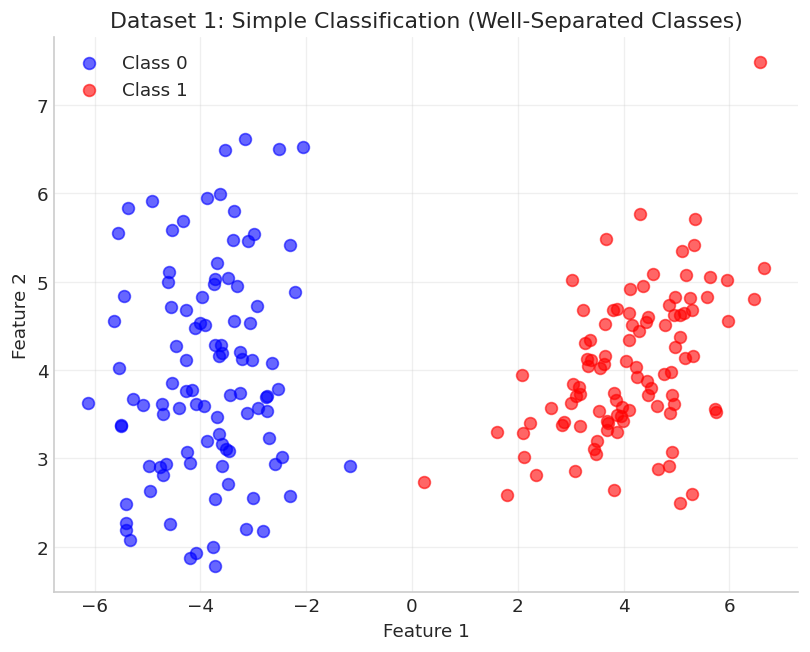


**Visualization Description:**
You should see two distinct clusters of points, one for each class.
The clusters are clearly separated with a visible gap between them.
This indicates that a linear decision boundary should easily separate the classes.


In [14]:
# Generate Dataset 1: Simple classification (well-separated classes)
from sklearn.datasets import make_classification

# Simple dataset: well-separated, no noise
X1, y1 = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=4.0,  # Large separation between classes
    flip_y=0.0,     # No noise
    random_state=42
)

print(f"Dataset 1 - Simple Classification")
print(f"Data shape: {X1.shape}")
print(f"Labels shape: {y1.shape}")
print(f"Class distribution: {np.bincount(y1)}")
print(f"Class separation: High (class_sep=2.0)")
print(f"Noise level: None (flip_y=0.0)")

# Visualize Dataset 1
plt.figure(figsize=(8, 6))
plt.scatter(X1[y1 == 0, 0], X1[y1 == 0, 1], c='blue', label='Class 0', alpha=0.6, s=50)
plt.scatter(X1[y1 == 1, 0], X1[y1 == 1, 1], c='red', label='Class 1', alpha=0.6, s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset 1: Simple Classification (Well-Separated Classes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n**Visualization Description:**")
print("You should see two distinct clusters of points, one for each class.")
print("The clusters are clearly separated with a visible gap between them.")
print("This indicates that a linear decision boundary should easily separate the classes.")

### Набір даних 2: Помірна складність (деяке перекриття)

**Характеристики набору даних:**
- Помірне розділення класів
- Присутній деякий шум
- 2 інформативні ознаки
- Деяке перекриття між класами

**Що очікувати:** Логістична регресія все ще має працювати добре, але може мати трохи нижчу точність через перекриття. Межа рішення матиме знайти найкраще розділення через область перекриття.

Dataset 2 - Moderate Complexity
Data shape: (200, 2)
Labels shape: (200,)
Class distribution: [ 97 103]
Class separation: Moderate (class_sep=1.0)
Noise level: Low (flip_y=0.05, 5% label noise)


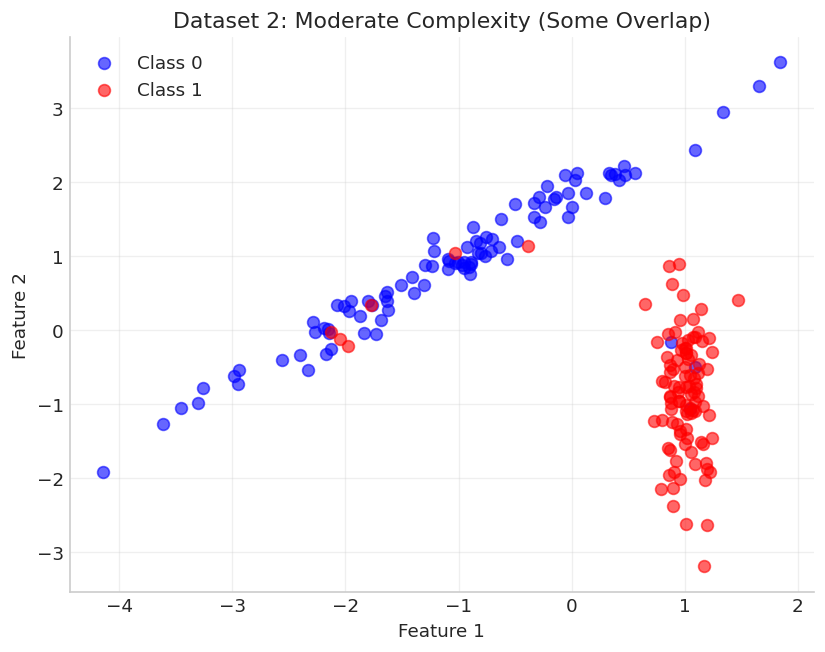


**Visualization Description:**
You should see two clusters with some overlap in the middle region.
There may be some mislabeled points (noise) visible as points of one color
in the region dominated by the other class.
The overlap makes classification more challenging but still manageable.


In [15]:
# Generate Dataset 2: Moderate complexity (some overlap, minimal noise)
X2, y2 = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.0,  # Moderate separation
    flip_y=0.05,    # 5% noise
    random_state=43
)

print(f"Dataset 2 - Moderate Complexity")
print(f"Data shape: {X2.shape}")
print(f"Labels shape: {y2.shape}")
print(f"Class distribution: {np.bincount(y2)}")
print(f"Class separation: Moderate (class_sep=1.0)")
print(f"Noise level: Low (flip_y=0.05, 5% label noise)")

# Visualize Dataset 2
plt.figure(figsize=(8, 6))
plt.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], c='blue', label='Class 0', alpha=0.6, s=50)
plt.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], c='red', label='Class 1', alpha=0.6, s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset 2: Moderate Complexity (Some Overlap)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n**Visualization Description:**")
print("You should see two clusters with some overlap in the middle region.")
print("There may be some mislabeled points (noise) visible as points of one color")
print("in the region dominated by the other class.")
print("The overlap makes classification more challenging but still manageable.")

### Набір даних 3: Складна класифікація (високе перекриття та шум)

**Характеристики набору даних:**
- Значне перекриття класів
- Вищий рівень шуму
- 2 інформативні ознаки (але з перекриттям)
- Може знадобитися нелінійна межа рішення

**Що очікувати:** Логістична регресія матиме більше труднощів з цим набором даних. Точність буде нижчою, і межа рішення може не ідеально розділити класи. Це демонструє обмеження лінійних класифікаторів.

Dataset 3 - Complex Classification
Data shape: (200, 2)
Labels shape: (200,)
Class distribution: [104  96]
Class separation: Low (class_sep=0.5, high overlap)
Noise level: High (flip_y=0.15, 15% label noise)


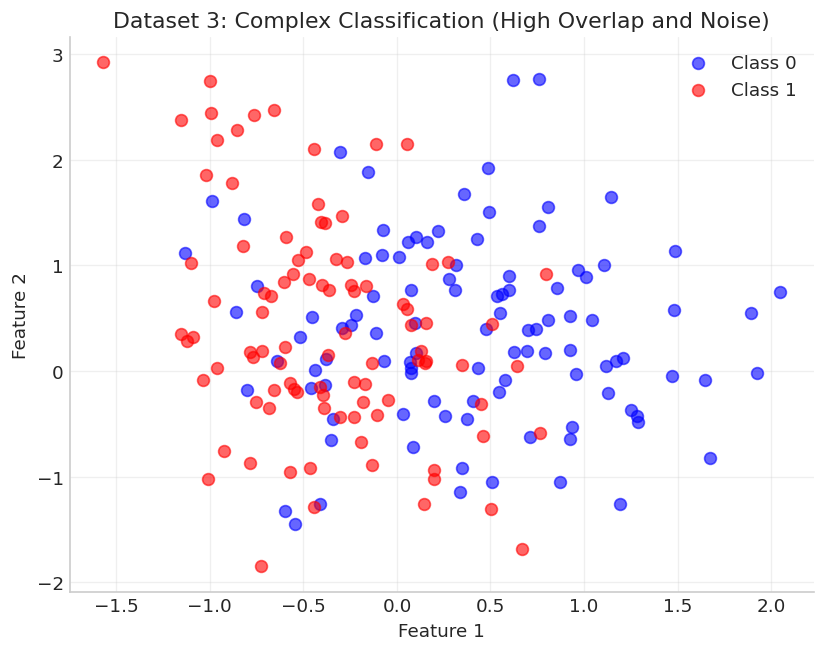


**Visualization Description:**
You should see significant overlap between the two classes.
The clusters are much closer together, and there are many mislabeled points
(noise) scattered throughout both regions.
This makes it difficult for a linear classifier to achieve perfect separation.
Some points will inevitably be misclassified due to the inherent overlap.


In [16]:
# Generate Dataset 3: Complex classification (high overlap, noise)
X3, y3 = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.5,  # Low separation (high overlap)
    flip_y=0.15,    # 15% noise
    random_state=44
)

print(f"Dataset 3 - Complex Classification")
print(f"Data shape: {X3.shape}")
print(f"Labels shape: {y3.shape}")
print(f"Class distribution: {np.bincount(y3)}")
print(f"Class separation: Low (class_sep=0.5, high overlap)")
print(f"Noise level: High (flip_y=0.15, 15% label noise)")

# Visualize Dataset 3
plt.figure(figsize=(8, 6))
plt.scatter(X3[y3 == 0, 0], X3[y3 == 0, 1], c='blue', label='Class 0', alpha=0.6, s=50)
plt.scatter(X3[y3 == 1, 0], X3[y3 == 1, 1], c='red', label='Class 1', alpha=0.6, s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset 3: Complex Classification (High Overlap and Noise)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n**Visualization Description:**")
print("You should see significant overlap between the two classes.")
print("The clusters are much closer together, and there are many mislabeled points")
print("(noise) scattered throughout both regions.")
print("This makes it difficult for a linear classifier to achieve perfect separation.")
print("Some points will inevitably be misclassified due to the inherent overlap.")

Тепер навчимо нашу модель логістичної регресії на всіх трьох наборах даних, щоб побачити, як вона працює за різних рівнів складності. Це допоможе нам зрозуміти поведінку алгоритму в різних умовах.

In [17]:
# Train on all three datasets and compare results
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# Results storage
results = []
all_models = []

# Test on all three datasets
datasets = [
    (X1, y1, "Dataset 1 (Simple)"),
    (X2, y2, "Dataset 2 (Moderate)"),
    (X3, y3, "Dataset 3 (Complex)")
]

for X, y, name in datasets:
    # Train our implementation
    w, b, losses = train_logistic_regression(X, y, learning_rate=0.1, epochs=1000)
    our_pred = predict(X, w, b)
    our_acc = compute_accuracy(y, our_pred)
    
    # Train sklearn implementation
    sklearn_model = LogisticRegression(random_state=42, max_iter=1000)
    sklearn_model.fit(X, y)
    sklearn_pred = sklearn_model.predict(X)
    sklearn_acc = accuracy_score(y, sklearn_pred)
    
    # Weight difference
    weight_diff = np.linalg.norm(w - sklearn_model.coef_[0])
    
    results.append({
        'Dataset': name,
        'Our Accuracy': f"{our_acc:.4f}",
        'sklearn Accuracy': f"{sklearn_acc:.4f}",
        'Accuracy Difference': f"{abs(our_acc - sklearn_acc):.6f}",
        'Weight Norm Difference': f"{weight_diff:.6f}"
    })
    
    all_models.append((X, y, w, b, name))

# Create comparison table
comparison_df = pd.DataFrame(results)
print("Algorithm Comparison Table")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

print("\n**What the comparison shows:**")
print("- Both implementations achieve similar accuracy on each dataset.")
print("- Simple datasets: High accuracy for both implementations")
print("- Complex datasets: Lower accuracy, showing linear classifier limitations")
print("- Small differences may occur due to different optimization algorithms.")

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.0139
Epoch 200, Loss: 0.0089
Epoch 300, Loss: 0.0070
Epoch 400, Loss: 0.0059
Epoch 500, Loss: 0.0053
Epoch 600, Loss: 0.0048
Epoch 700, Loss: 0.0044
Epoch 800, Loss: 0.0041
Epoch 900, Loss: 0.0039
Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.2062
Epoch 200, Loss: 0.1905
Epoch 300, Loss: 0.1860
Epoch 400, Loss: 0.1841
Epoch 500, Loss: 0.1831
Epoch 600, Loss: 0.1825
Epoch 700, Loss: 0.1822
Epoch 800, Loss: 0.1820
Epoch 900, Loss: 0.1819
Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.5476
Epoch 200, Loss: 0.5248
Epoch 300, Loss: 0.5189
Epoch 400, Loss: 0.5170
Epoch 500, Loss: 0.5164
Epoch 600, Loss: 0.5161
Epoch 700, Loss: 0.5160
Epoch 800, Loss: 0.5160
Epoch 900, Loss: 0.5160
Algorithm Comparison Table
             Dataset Our Accuracy sklearn Accuracy Accuracy Difference Weight Norm Difference
  Dataset 1 (Simple)       1.0000           1.0000            0.000000               0.479481
Dataset 2 (Moderate)       0.9550           0.9550            0.000000 

## Експерименти з гіперпараметрами: швидкість навчання

Проведемо експерименти з різними швидкостями навчання, щоб побачити, як вони впливають на навчання. Це допоможе нам зрозуміти важливість налаштування гіперпараметрів у машинному навчанні.

Hyperparameter Experimentation: Learning Rate
Testing on Dataset 2 (Moderate Complexity)
Epochs: 1000
Epoch 0, Loss: 0.6931, ||w||: 0.0002
Epoch 100, Loss: 0.6894, ||w||: 0.0195
Epoch 200, Loss: 0.6857, ||w||: 0.0385
Epoch 300, Loss: 0.6822, ||w||: 0.0573
Epoch 400, Loss: 0.6787, ||w||: 0.0758
Epoch 500, Loss: 0.6753, ||w||: 0.0941
Epoch 600, Loss: 0.6720, ||w||: 0.1122
Epoch 700, Loss: 0.6688, ||w||: 0.1300
Epoch 800, Loss: 0.6657, ||w||: 0.1476
Epoch 900, Loss: 0.6626, ||w||: 0.1650
Epoch 0, Loss: 0.6931, ||w||: 0.0019
Epoch 100, Loss: 0.6597, ||w||: 0.1838
Epoch 200, Loss: 0.6337, ||w||: 0.3442
Epoch 300, Loss: 0.6134, ||w||: 0.4861
Epoch 400, Loss: 0.5973, ||w||: 0.6125
Epoch 500, Loss: 0.5845, ||w||: 0.7256
Epoch 600, Loss: 0.5741, ||w||: 0.8273
Epoch 700, Loss: 0.5656, ||w||: 0.9194
Epoch 800, Loss: 0.5585, ||w||: 1.0030
Epoch 900, Loss: 0.5527, ||w||: 1.0792
Epoch 0, Loss: 0.6931, ||w||: 0.0194
Epoch 100, Loss: 0.5476, ||w||: 1.1582
Epoch 200, Loss: 0.5248, ||w||: 1.6208
Epoch 3

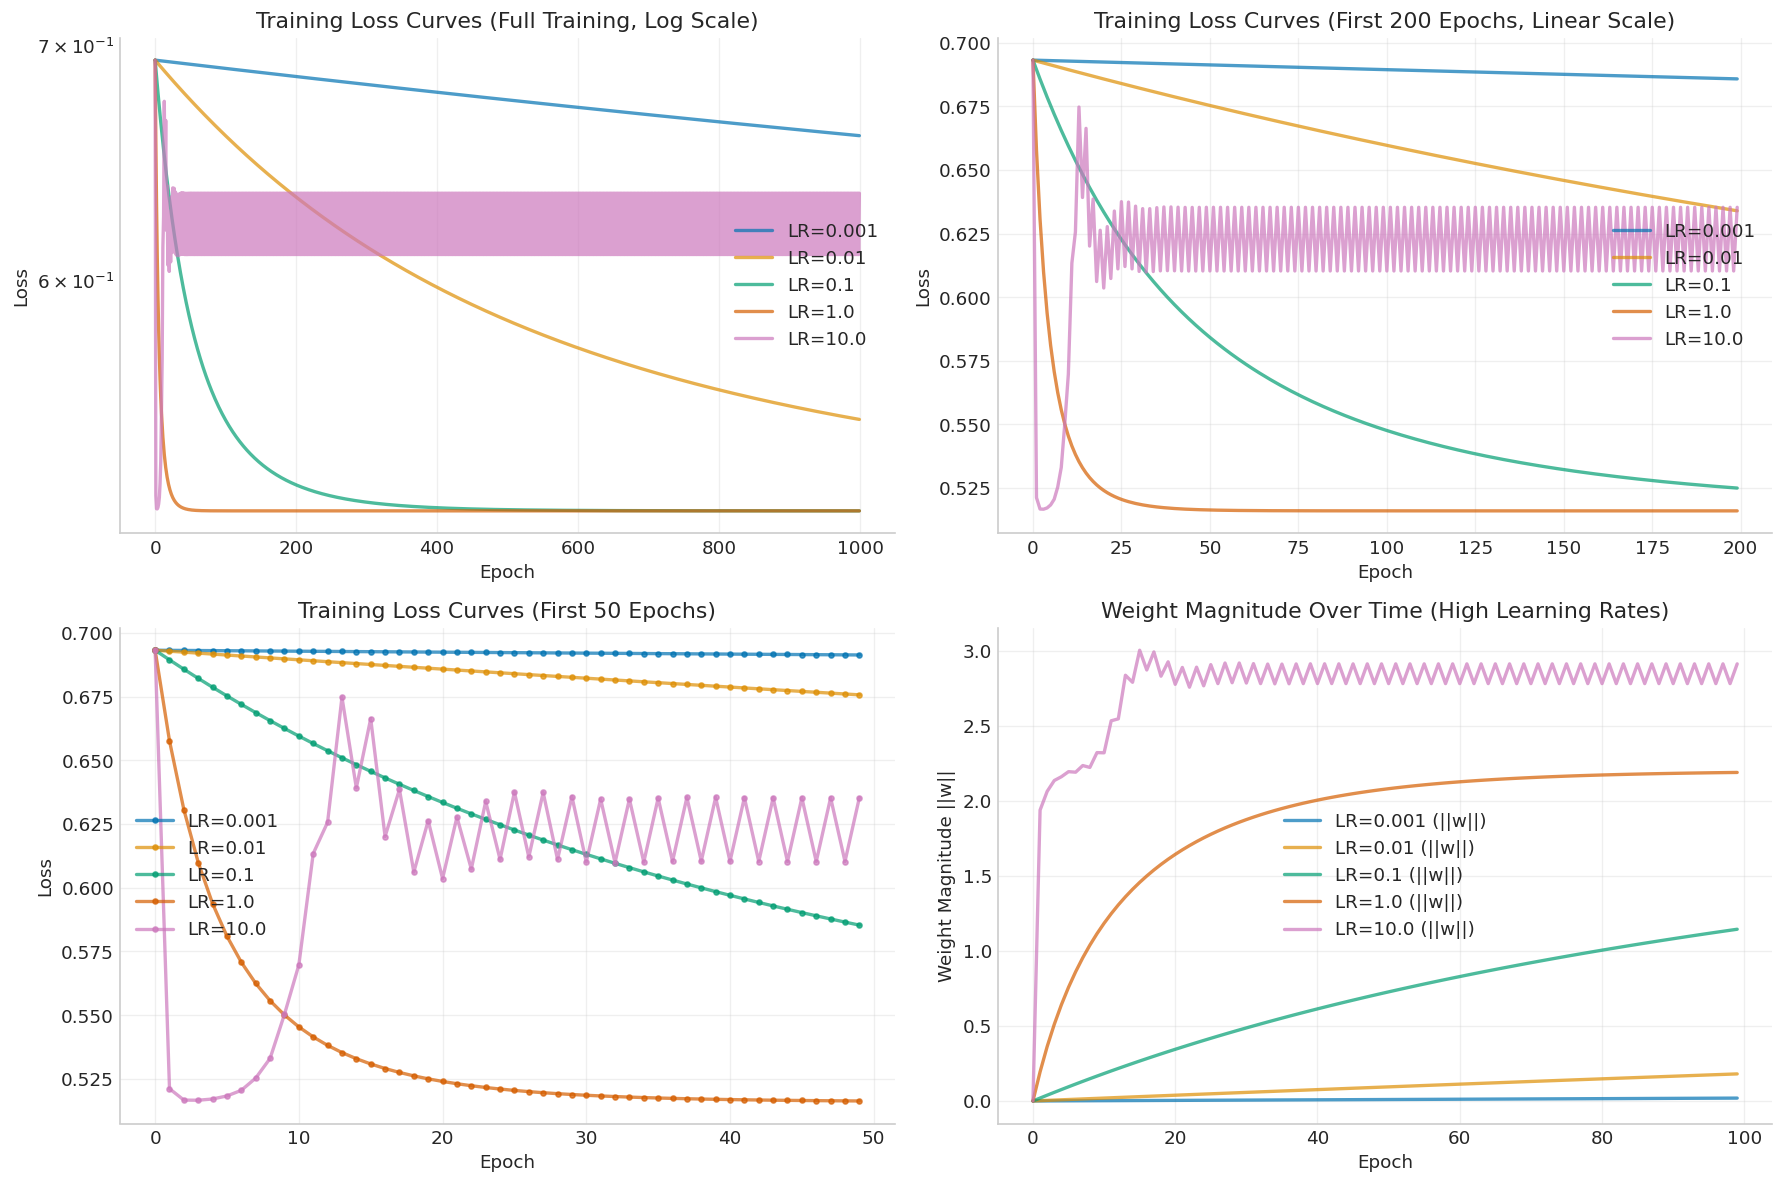


**Visualization Description:**
You should see different training curves for each learning rate:
- Very small learning rates (0.001): Slow convergence, smooth curve
- Moderate learning rates (0.01, 0.1): Good convergence, smooth curve
- Large learning rates (1.0, 10.0): May oscillate, show jagged/irregular curves
- The early epochs plot (linear scale) better shows oscillations and instability
- High learning rates (especially 10.0) should show spikes in weight magnitude
- The weight magnitude plot shows actual parameter instability during training
- The optimal learning rate achieves fast convergence without instability.


In [18]:
# Experiment with different learning rates - use even higher values and track weights
learning_rates = [0.001, 0.01, 0.1, 1.0, 10.0]  # Added 10.0
epochs = 1000

print("Hyperparameter Experimentation: Learning Rate")
print("=" * 70)
print(f"Testing on Dataset 2 (Moderate Complexity)")
print(f"Epochs: {epochs}")
print("=" * 70)

results_lr = []
weight_histories = {}

for lr in learning_rates:
    # Track weights for high learning rates
    track = (lr >= 1.0)
    w_exp, b_exp, losses_exp, w_history = train_logistic_regression_with_weights(
        X3, y3, learning_rate=lr, epochs=epochs, track_weights=track
    )
    pred_exp = predict(X3, w_exp, b_exp)
    acc_exp = compute_accuracy(y3, pred_exp)
    final_loss = losses_exp[-1]
    
    # Check for NaN or Inf values (signs of instability)
    has_nan = np.isnan(losses_exp).any() or np.isnan(w_exp).any() or np.isnan(b_exp)
    has_inf = np.isinf(losses_exp).any() or np.isinf(w_exp).any() or np.isinf(b_exp)
    
    results_lr.append({
        'Learning Rate': lr,
        'Final Accuracy': f"{acc_exp:.4f}",
        'Final Loss': f"{final_loss:.6f}",
        'Converged': 'Yes' if len(losses_exp) > 100 and abs(losses_exp[-1] - losses_exp[-100]) < 0.001 else 'No',
        'Has NaN/Inf': 'Yes' if (has_nan or has_inf) else 'No'
    })
    
    if track and w_history:
        weight_histories[lr] = w_history

# Create comparison table
lr_df = pd.DataFrame(results_lr)
print("\n" + "=" * 70)
print("Learning Rate Comparison Table")
print("=" * 70)
print(lr_df.to_string(index=False))
print("=" * 70)

# Visualize training curves for different learning rates
plt.figure(figsize=(15, 10))

# Plot 1: Full training curves (log scale)
plt.subplot(2, 2, 1)
for lr in learning_rates:
    w_vis, b_vis, losses_vis, _ = train_logistic_regression_with_weights(
        X3, y3, learning_rate=lr, epochs=epochs, track_weights=False
    )
    plt.plot(losses_vis, label=f'LR={lr}', alpha=0.7, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves (Full Training, Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 2: Early epochs (linear scale) - shows oscillations better
plt.subplot(2, 2, 2)
early_epochs = 200
for lr in learning_rates:
    w_vis, b_vis, losses_vis, _ = train_logistic_regression_with_weights(
        X3, y3, learning_rate=lr, epochs=epochs, track_weights=False
    )
    plt.plot(losses_vis[:early_epochs], label=f'LR={lr}', alpha=0.7, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training Loss Curves (First {early_epochs} Epochs, Linear Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Very early epochs (first 50) - zoom in on instability
plt.subplot(2, 2, 3)
very_early_epochs = 50
for lr in learning_rates:
    w_vis, b_vis, losses_vis, _ = train_logistic_regression_with_weights(
        X3, y3, learning_rate=lr, epochs=epochs, track_weights=False
    )
    plt.plot(losses_vis[:very_early_epochs], label=f'LR={lr}', alpha=0.7, linewidth=2, marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training Loss Curves (First {very_early_epochs} Epochs)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Weight magnitude over time using ACTUAL training history
plt.subplot(2, 2, 4)
for lr in learning_rates:
    if lr in weight_histories:
        weight_mags = [wh['weight_mag'] for wh in weight_histories[lr][:100]]  # First 100 epochs
        plt.plot(weight_mags, label=f'LR={lr} (||w||)', alpha=0.7, linewidth=2)
    else:
        # Fallback: track during training
        w_vis, b_vis, losses_vis, w_history = train_logistic_regression_with_weights(
            X3, y3, learning_rate=lr, epochs=100, track_weights=True
        )
        if w_history:
            weight_mags = [wh['weight_mag'] for wh in w_history]
            plt.plot(weight_mags, label=f'LR={lr} (||w||)', alpha=0.7, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Weight Magnitude ||w||')
plt.title('Weight Magnitude Over Time (High Learning Rates)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n**Visualization Description:**")
print("You should see different training curves for each learning rate:")
print("- Very small learning rates (0.001): Slow convergence, smooth curve")
print("- Moderate learning rates (0.01, 0.1): Good convergence, smooth curve")
print("- Large learning rates (1.0, 10.0): May oscillate, show jagged/irregular curves")
print("- The early epochs plot (linear scale) better shows oscillations and instability")
print("- High learning rates (especially 10.0) should show spikes in weight magnitude")
print("- The weight magnitude plot shows actual parameter instability during training")
print("- The optimal learning rate achieves fast convergence without instability.")

## Підсумок



### Ключові концепції, які ми вивчили

- Функція логістичної втрати

- Оптимізація градієнтним спуском

- Візуалізація межі рішення

- Бінарна класифікація



### Підсумок
Логістична регресія - це базовий алгоритм класифікації, який можна реалізувати з нуля, використовуючи базові техніки оптимізації.
